# Experiment 2b — Closing the linear-vs-GBR gap

**Context.** In Experiment 2, the Stage-2 linear winner per policy had
roughly 3x the MAE of Feature X + GBR, with a systematic negative bias of
$-0.02$ to $-0.03$.  Inspection of the data showed that 25-40% of seller
turns live in two *discrete modes* that no smooth linear-in-logit function
can capture:

* **at-floor (absorbing)** — once $S_{t-1} < 0.1$, the next ask is
  essentially pinned at $0$.  The ordinary linear model predicts a smooth
  concession-slope through this region, causing bias.
* **stagnation** — when the buyer barely moves, the seller often holds
  their previous ask exactly.  Again, the linear model predicts a small
  concession anyway.

We test two fixes that keep the *linear-in-parameters* form intact:

* **Approach A** — augment the feature set with three mode-predictive
  indicators and one floor-interaction term.
* **Approach B** — piecewise linear with a mode $\times$ features
  interaction expansion (equivalent to three separate Ridge models, one
  per mode, fit jointly).

For each policy we compare the two fixes against vanilla linear and the
GBR ceiling, all on the same 10-fold grouped + vehicle-stratified CV.

## 1. Setup and data

In [2]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import negolin_utils as nu
nu.setup_matplotlib()

nu.RAND_BUYER_DIR = Path('../0421_redo_previous_exp/results')
raw = nu.load_all_fixed_policies(nu.RAND_BUYER_DIR)
_, turns = nu.preprocess_turns(raw)
POLICIES = list(nu.POLICIES)
print(f'Clean analysis turns: {int((~turns["parse_fail"]).sum()):,}')

Clean analysis turns: 6,234


## 2. Mode indicators: what predicts which discrete mode?

Before constructing features, we verify the mode-predictive behaviour of
each candidate indicator on pooled data.

In [3]:
# Define observed modes from y (for diagnosis only — not used in fitting)
def assign_observed_mode(d):
    m = pd.Series('concede', index=d.index)
    m[d['S_norm'] < 0.05] = 'reject'
    m[np.isclose(d['S_norm'], d['S_lag1'], atol=1e-3) & (d['S_norm'] >= 0.05)] = 'persist'
    return m

clean = turns[(~turns['parse_fail']) & turns['round'].between(3, 12)].copy()
clean['mode_obs'] = assign_observed_mode(clean)

mode_dist = clean.groupby('policy')['mode_obs'].value_counts(normalize=True).unstack().round(3)
print('Observed mode distribution per policy:')
print(mode_dist)

# Check indicator lifts for pooled data
print('\nIndicator lifts (P(mode | indicator) / P(mode)):')
tests = [
    ('I_at_floor  (S_lag1 < 0.1)',        clean['S_lag1'] < 0.1),
    ('I_big_gap   (S_lag1 - B_norm > 0.5)', (clean['S_lag1'] - clean['B_norm']) > 0.5),
    ('I_retreat   (dB < -0.1)',           clean['dB'] < -0.1),
]
base_rej = (clean['mode_obs'] == 'reject').mean()
base_per = (clean['mode_obs'] == 'persist').mean()
for label, cond in tests:
    p_rej = (clean.loc[cond, 'mode_obs'] == 'reject').mean()
    p_per = (clean.loc[cond, 'mode_obs'] == 'persist').mean()
    print(f'  {label:42s}  rate={cond.mean():.3f}   '
          f'lift[reject]={p_rej/base_rej:5.1f}x   lift[persist]={p_per/base_per:5.1f}x')

Observed mode distribution per policy:
mode_obs  concede  persist  reject
policy                            
FRB         0.750    0.073   0.178
IC          0.740    0.135   0.125
MEVJ        0.702    0.245   0.053
OADS        0.764    0.120   0.116
PVD         0.768    0.164   0.068
RFK         0.690    0.225   0.085

Indicator lifts (P(mode | indicator) / P(mode)):
  I_at_floor  (S_lag1 < 0.1)                  rate=0.137   lift[reject]=  7.1x   lift[persist]=  0.5x
  I_big_gap   (S_lag1 - B_norm > 0.5)         rate=0.566   lift[reject]=  0.3x   lift[persist]=  1.4x
  I_retreat   (dB < -0.1)                     rate=0.413   lift[reject]=  0.7x   lift[persist]=  1.6x


## 3. Approach A — indicator-augmented design matrix

The base feature map is X (the most expressive spec in the original grid).
We augment with:

- `I_at_floor    = 1[S_{t-1} < 0.1]`
- `I_big_gap     = 1[S_{t-1} - B_t > 0.5]`
- `I_retreat     = 1[dB_t < -0.1]`
- `I_floor_x_Slag1 = I_at_floor * S_{t-1}`   (optional)

All four are linear in parameters; only the first three are non-smooth in
the input.

In [4]:
def build_augmented(turns, policy, base='X', floor_interaction=True):
    meta, X, y, cols = nu.build_design_matrix(turns, policy, base)
    extras = []
    extra_cols = []
    extras.append((meta['S_lag1'] < 0.1).astype(float).to_numpy().reshape(-1, 1))
    extra_cols.append('I_at_floor')
    extras.append(((meta['S_lag1'] - meta['B_norm']) > 0.5).astype(float).to_numpy().reshape(-1, 1))
    extra_cols.append('I_big_gap')
    extras.append((meta['dB'] < -0.1).astype(float).to_numpy().reshape(-1, 1))
    extra_cols.append('I_retreat')
    if floor_interaction and 'S_lag1' in cols:
        j = cols.index('S_lag1')
        I_floor = (meta['S_lag1'] < 0.1).astype(float).to_numpy()
        extras.append((I_floor * X[:, j]).reshape(-1, 1))
        extra_cols.append('I_floor_x_Slag1')
    X_aug = np.hstack([X] + extras)
    return meta, X_aug, y, cols + extra_cols

# Sanity-check the augmented builder
meta, X, y, cols = build_augmented(turns, 'PVD')
print(f'PVD augmented X: shape={X.shape}, new cols = {cols[-4:]}')

PVD augmented X: shape=(660, 11), new cols = ['I_at_floor', 'I_big_gap', 'I_retreat', 'I_floor_x_Slag1']


## 4. Approach B — piecewise linear via mode-by-features interactions

Three modes defined from features alone (no target leakage):

- `at_floor`  — `S_{t-1} < 0.1`
- `stagnant`  — `|dB_t| < 0.02` and not at-floor
- `active`    — otherwise

The design matrix is a block-diagonal expansion
$\phi_{\text{pw}}(X_t) = [1_m \cdot (1, B_t, S_{t-1}, dB_t)]_{m \in \text{modes}}$,
so the jointly-fit Ridge returns three mode-specific intercept+slope
vectors.  Total parameters: 3 modes x 4 coefficients = 12 (vs 8 for
Approach A).

In [5]:
def build_piecewise(turns, policy):
    meta, X, y, cols = nu.build_design_matrix(turns, policy, 'VIII')
    # VIII cols are [B_norm, S_lag1, dB] - exactly what we need
    # Build [1, B_norm, S_lag1, dB] with explicit intercept
    X_ext = np.hstack([np.ones((len(X), 1)), X])
    base_cols = ['const'] + cols        # 4 cols

    S_lag1 = meta['S_lag1'].to_numpy()
    dB     = meta['dB'].to_numpy()
    m_floor = (S_lag1 < 0.1).astype(float)
    m_stag  = ((np.abs(dB) < 0.02) & (S_lag1 >= 0.1)).astype(float)
    m_act   = 1.0 - m_floor - m_stag

    blocks = []
    out_cols = []
    for tag, mvec in [('floor', m_floor), ('stag', m_stag), ('act', m_act)]:
        blocks.append(X_ext * mvec.reshape(-1, 1))
        out_cols += [f'{c}_x_{tag}' for c in base_cols]
    return meta, np.hstack(blocks), y, out_cols

meta, Xpw, ypw, colspw = build_piecewise(turns, 'PVD')
print(f'PVD piecewise design: shape={Xpw.shape}  cols={colspw}')

PVD piecewise design: shape=(660, 12)  cols=['const_x_floor', 'B_norm_x_floor', 'S_lag1_x_floor', 'dB_x_floor', 'const_x_stag', 'B_norm_x_stag', 'S_lag1_x_stag', 'dB_x_stag', 'const_x_act', 'B_norm_x_act', 'S_lag1_x_act', 'dB_x_act']


## 5. Run the four-way comparison

For every policy, fit and CV:

1. **Vanilla linear** — Feature X + Ridge (no indicator, no piecewise)
2. **Augmented linear (A)** — Feature X + 3 indicators + floor interaction + Ridge
3. **Piecewise linear (B)** — mode-by-VIII expansion + Ridge
4. **GBR ceiling** — Feature X + GBR (reference)

All use the same 10-fold grouped + vehicle-stratified CV.

In [6]:
def eval_candidate(meta, X, y, model_name):
    pred, _ = nu.grouped_cv_predict(meta, X, y, model_name, n_splits=nu.OUTER_FOLDS)
    return nu.cv_metrics_full(pred), pred

rows = []
oof = {}
for pol in POLICIES:
    # vanilla
    meta_x, Xx, yx, _  = nu.build_design_matrix(turns, pol, 'X')
    m_v, oof[(pol,'vanilla')] = eval_candidate(meta_x, Xx, yx, 'Ridge')
    rows.append({'policy': pol, 'approach': 'vanilla (Feature X + Ridge)',
                 'dim': Xx.shape[1], **m_v})

    # augmented (Approach A)
    meta_a, Xa, ya, _ = build_augmented(turns, pol, base='X', floor_interaction=True)
    m_a, oof[(pol,'augmented')] = eval_candidate(meta_a, Xa, ya, 'Ridge')
    rows.append({'policy': pol, 'approach': 'augmented (A) = X + 3 inds + floor x S_lag1',
                 'dim': Xa.shape[1], **m_a})

    # piecewise (Approach B)
    meta_p, Xp, yp, _ = build_piecewise(turns, pol)
    m_p, oof[(pol,'piecewise')] = eval_candidate(meta_p, Xp, yp, 'Ridge')
    rows.append({'policy': pol, 'approach': 'piecewise (B) = 3 modes x VIII',
                 'dim': Xp.shape[1], **m_p})

    # GBR ceiling
    m_g, oof[(pol,'gbr')] = eval_candidate(meta_x, Xx, yx, 'GBR')
    rows.append({'policy': pol, 'approach': 'GBR ceiling (Feature X + GBR)',
                 'dim': Xx.shape[1], **m_g})

results = pd.DataFrame(rows)
results['gap_to_gbr'] = (results['mae_norm']
                         - results.groupby('policy')['mae_norm'].transform('min'))
# For clarity: report selected columns
view = results[['policy','approach','dim','mae_norm','mae_norm_se','bias','r2','gap_to_gbr']].copy()
view[['mae_norm','mae_norm_se','bias','gap_to_gbr']] = view[['mae_norm','mae_norm_se','bias','gap_to_gbr']].round(4)
view['r2'] = view['r2'].round(3)
print(view.to_string(index=False))

policy                                    approach  dim  mae_norm  mae_norm_se    bias    r2  gap_to_gbr
   PVD                 vanilla (Feature X + Ridge)    7    0.0590       0.0052 -0.0216 0.915      0.0373
   PVD augmented (A) = X + 3 inds + floor x S_lag1   11    0.0280       0.0021  0.0018 0.975      0.0063
   PVD              piecewise (B) = 3 modes x VIII   12    0.0292       0.0020  0.0042 0.975      0.0075
   PVD               GBR ceiling (Feature X + GBR)    7    0.0217       0.0015 -0.0010 0.985      0.0000
    IC                 vanilla (Feature X + Ridge)    7    0.0726       0.0041 -0.0247 0.862      0.0399
    IC augmented (A) = X + 3 inds + floor x S_lag1   11    0.0367       0.0028 -0.0030 0.942      0.0039
    IC              piecewise (B) = 3 modes x VIII   12    0.0359       0.0021 -0.0031 0.948      0.0031
    IC               GBR ceiling (Feature X + GBR)    7    0.0328       0.0024 -0.0033 0.951      0.0000
   FRB                 vanilla (Feature X + Ridge)    7

## 6. Summary table: best linear (A or B) vs best GBR, per policy

In [7]:
# Pick the best of {augmented, piecewise} per policy
def best_of(df, labels):
    sub = df[df['approach'].str.contains('|'.join(labels), regex=True)]
    return sub.loc[sub.groupby('policy')['mae_norm'].idxmin()].reset_index(drop=True)

best_lin = best_of(results, ['augmented', 'piecewise']).rename(
    columns={'approach': 'best_linear_approach', 'mae_norm': 'best_linear_mae',
             'bias': 'best_linear_bias', 'r2': 'best_linear_r2'})
best_gbr = results[results['approach'].str.contains('GBR')].rename(
    columns={'mae_norm': 'gbr_mae', 'bias': 'gbr_bias', 'r2': 'gbr_r2'})
vanilla  = results[results['approach'].str.contains('vanilla')].rename(
    columns={'mae_norm': 'vanilla_mae'})

summary = (vanilla[['policy','vanilla_mae']]
           .merge(best_lin[['policy','best_linear_approach','best_linear_mae',
                             'best_linear_bias','best_linear_r2']], on='policy')
           .merge(best_gbr[['policy','gbr_mae','gbr_bias','gbr_r2']], on='policy'))
summary['gap_vanilla']  = (summary['vanilla_mae']     - summary['gbr_mae']).round(4)
summary['gap_best_lin'] = (summary['best_linear_mae'] - summary['gbr_mae']).round(4)
summary['mae_reduction_pct'] = (
    (summary['vanilla_mae'] - summary['best_linear_mae']) / summary['vanilla_mae'] * 100
).round(1)
summary[['vanilla_mae','best_linear_mae','gbr_mae',
         'best_linear_bias','gbr_bias','best_linear_r2','gbr_r2']] = (
    summary[['vanilla_mae','best_linear_mae','gbr_mae',
             'best_linear_bias','gbr_bias','best_linear_r2','gbr_r2']].round(4))
print('Per-policy comparison:')
print(summary.to_string(index=False))

Per-policy comparison:
policy  vanilla_mae                        best_linear_approach  best_linear_mae  best_linear_bias  best_linear_r2  gbr_mae  gbr_bias  gbr_r2  gap_vanilla  gap_best_lin  mae_reduction_pct
   PVD       0.0590 augmented (A) = X + 3 inds + floor x S_lag1           0.0280            0.0018          0.9753   0.0217   -0.0010  0.9854       0.0373        0.0063               52.5
    IC       0.0726              piecewise (B) = 3 modes x VIII           0.0359           -0.0031          0.9485   0.0328   -0.0033  0.9509       0.0399        0.0031               50.6
   FRB       0.0794 augmented (A) = X + 3 inds + floor x S_lag1           0.0323           -0.0001          0.9666   0.0252   -0.0032  0.9786       0.0542        0.0071               59.3
   RFK       0.0546              piecewise (B) = 3 modes x VIII           0.0376            0.0118          0.9673   0.0247   -0.0002  0.9822       0.0299        0.0129               31.2
  OADS       0.0800              piec

## 7. Visualization: pred-vs-actual, three approaches side by side

For each policy, overlay three scatter plots:
vanilla linear | augmented linear | GBR ceiling.
Read left to right: each step should tighten around the 45° line.

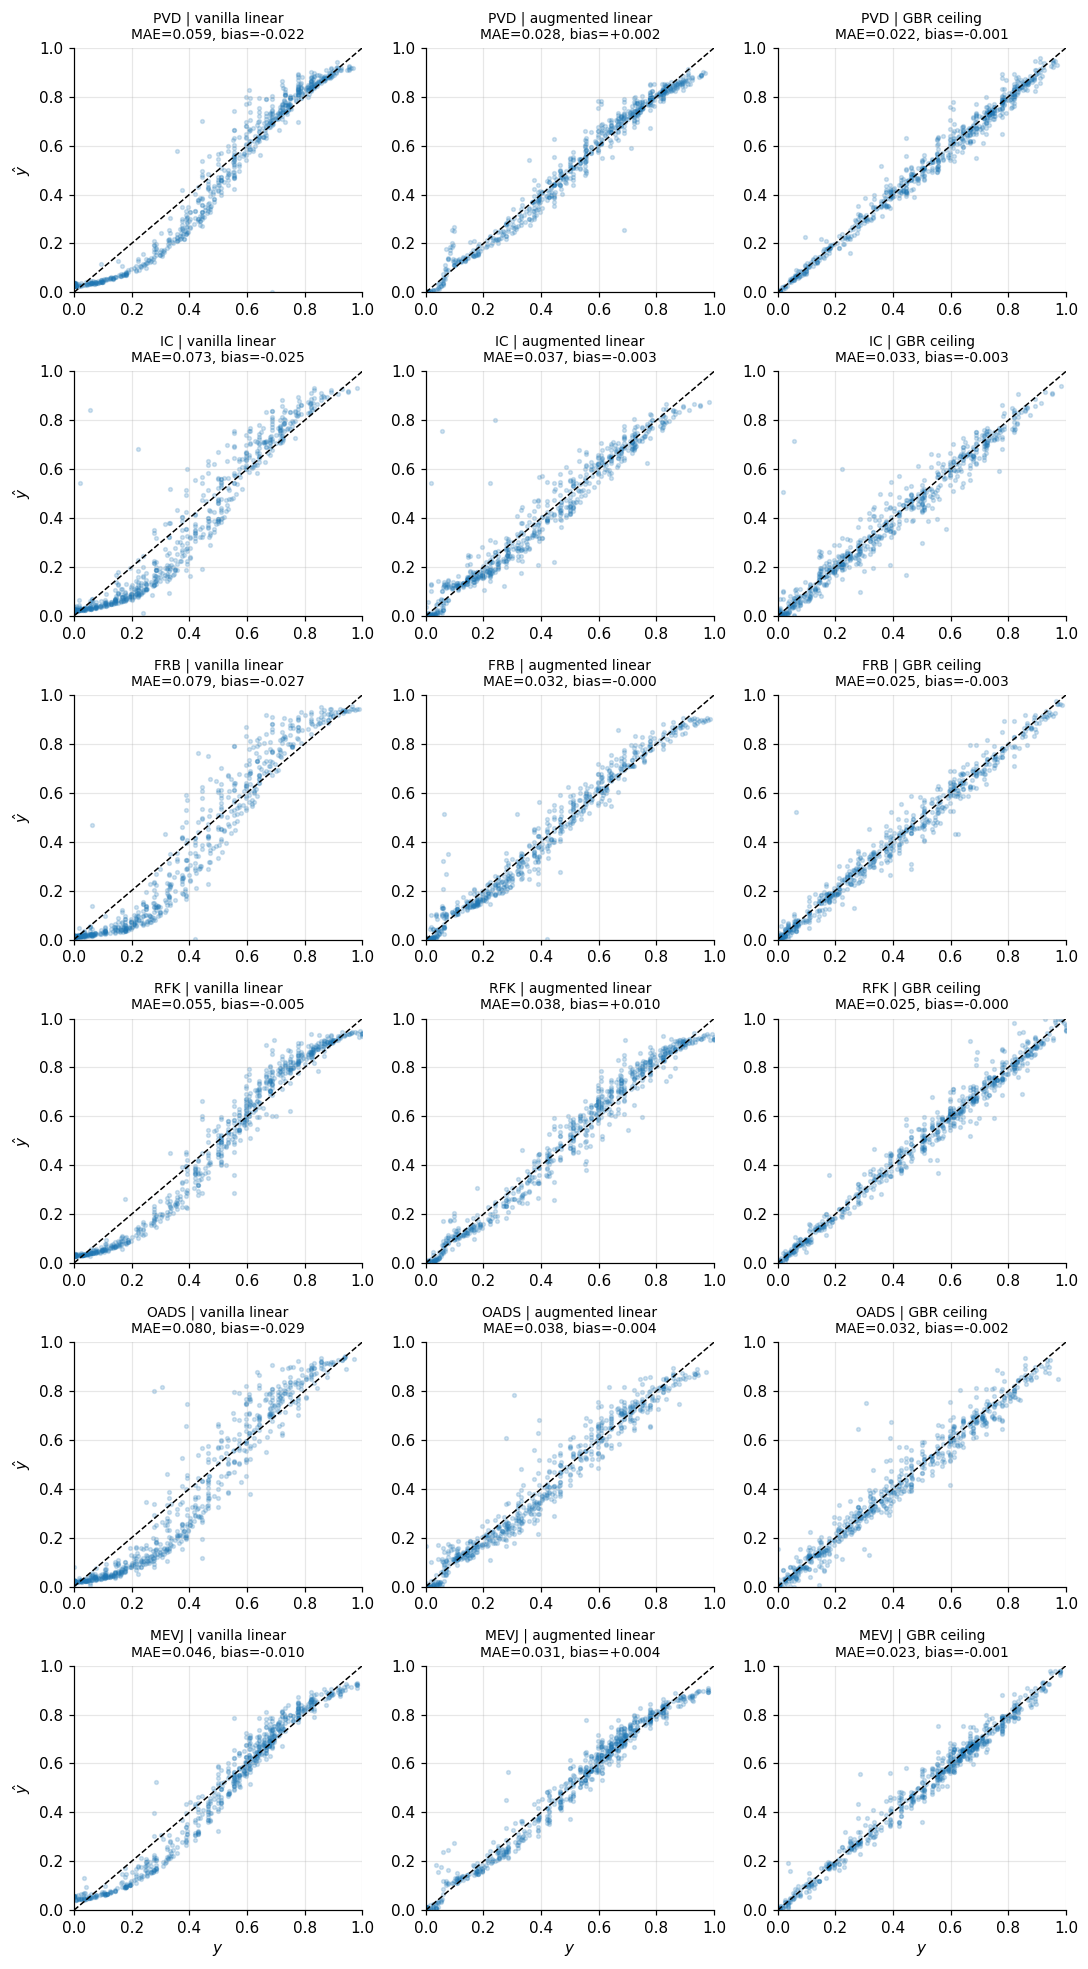

In [8]:
fig, axes = plt.subplots(6, 3, figsize=(10, 18))
for i, pol in enumerate(POLICIES):
    for j, (label, key) in enumerate([
        ('vanilla linear',   (pol, 'vanilla')),
        ('augmented linear', (pol, 'augmented')),
        ('GBR ceiling',      (pol, 'gbr')),
    ]):
        ax = axes[i, j]
        pred_df = oof[key]
        ax.scatter(pred_df['y_true'], pred_df['y_pred'], s=6, alpha=0.2)
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        m = nu.cv_metrics_full(pred_df)
        ax.set_title(f'{pol} | {label}\nMAE={m["mae_norm"]:.3f}, bias={m["bias"]:+.3f}',
                     fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        if j == 0:
            ax.set_ylabel(r'$\hat y$')
        if i == 5:
            ax.set_xlabel(r'$y$')
plt.tight_layout()
plt.savefig('figE2b_pred_vs_actual.png', dpi=140, bbox_inches='tight')
plt.show()

## 8. Where did the bias go?  Mode-conditional error check

The original diagnosis was that negative bias comes from persistence-mode
observations (where the linear model predicts a small concession but the
truth is no concession). Let's verify: for each approach, compute the bias
*conditional on observed mode*.

In [9]:
def mode_conditional_bias(pred_df):
    d = pred_df.copy()
    d['mode_obs'] = assign_observed_mode(d)
    g = d.groupby('mode_obs').apply(
        lambda x: pd.Series({
            'n': len(x),
            'share': len(x) / len(d),
            'mae': np.mean(np.abs(x['y_pred'] - x['y_true'])),
            'bias': np.mean(x['y_pred'] - x['y_true']),
        }), include_groups=False)
    return g

# Show for PVD (the policy where bias was most dramatic)
pol = 'PVD'
for label, key in [('vanilla', 'vanilla'), ('augmented', 'augmented'),
                    ('piecewise', 'piecewise'), ('GBR', 'gbr')]:
    print(f'\n=== {pol} - {label} ===')
    tbl = mode_conditional_bias(oof[(pol, key)])
    print(tbl.round(4))


=== PVD - vanilla ===
              n   share     mae    bias
mode_obs                               
concede   507.0  0.7682  0.0626 -0.0197
persist   108.0  0.1636  0.0573 -0.0483
reject     45.0  0.0682  0.0228  0.0202

=== PVD - augmented ===
              n   share     mae    bias
mode_obs                               
concede   507.0  0.7682  0.0295  0.0065
persist   108.0  0.1636  0.0297 -0.0168
reject     45.0  0.0682  0.0071 -0.0060

=== PVD - piecewise ===
              n   share     mae    bias
mode_obs                               
concede   507.0  0.7682  0.0301  0.0102
persist   108.0  0.1636  0.0339 -0.0197
reject     45.0  0.0682  0.0076 -0.0064

=== PVD - GBR ===
              n   share     mae    bias
mode_obs                               
concede   507.0  0.7682  0.0225  0.0042
persist   108.0  0.1636  0.0260 -0.0258
reject     45.0  0.0682  0.0027 -0.0001


## 9. Coefficient inspection for the augmented linear model

Which indicator actually absorbed the bias? Fit once on all data per policy
and show standardized coefficients.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

coef_rows = []
for pol in POLICIES:
    meta, X, y, cols = build_augmented(turns, pol, base='X', floor_interaction=True)
    scaler = StandardScaler().fit(X)
    reg = Ridge(alpha=1.0).fit(scaler.transform(X), nu.logit_clip(y))
    for c, val in zip(cols, reg.coef_):
        coef_rows.append({'policy': pol, 'term': c, 'coef_std': float(val)})
    coef_rows.append({'policy': pol, 'term': 'intercept',
                       'coef_std': float(reg.intercept_)})

coef = (pd.DataFrame(coef_rows)
          .pivot(index='term', columns='policy', values='coef_std')
          .reindex(columns=POLICIES))
print('Standardized coefficients, augmented linear model:')
print(coef.round(3))

Standardized coefficients, augmented linear model:
policy             PVD     IC    FRB    RFK   OADS   MEVJ
term                                                     
B_norm_neg       0.001  0.012  0.009 -0.051 -0.023  0.004
B_norm_pos       0.049  0.016  0.058  0.090 -0.015  0.042
I_at_floor      -1.339 -1.522 -1.991 -1.112 -1.723 -0.994
I_big_gap        0.036 -0.033  0.002  0.056 -0.076  0.009
I_floor_x_Slag1  0.870  0.844  1.170  0.757  1.036  0.650
I_retreat        0.054 -0.034 -0.013  0.055 -0.072  0.041
S_lag1           1.311  1.271  1.418  1.511  1.406  1.250
dB_neg           0.001  0.035  0.034  0.032  0.052 -0.006
dB_pos          -0.054 -0.101 -0.077 -0.145 -0.156 -0.074
dS_lag1_neg     -0.082 -0.039 -0.083 -0.099 -0.035 -0.064
dS_lag1_pos     -0.013  0.017 -0.012  0.016 -0.013  0.000
intercept       -0.218 -1.066 -1.275 -0.214 -0.991 -0.081


## 10. Save results for the paper

In [11]:
OUT = Path('latex_tables'); OUT.mkdir(exist_ok=True)

summary.to_csv('exp02b_linear_vs_gbr.csv', index=False)
coef.to_csv('exp02b_augmented_coefficients.csv')

# Compact LaTeX table: per-policy comparison
import io
buf = io.StringIO()
buf.write(r'\begin{table}[t]' + '\n')
buf.write(r'\centering' + '\n')
buf.write(r'\caption{Augmented linear models close most of the linear-to-GBR gap. '
          r'Numbers are normalized MAE from 10-fold grouped + vehicle-stratified CV.}' + '\n')
buf.write(r'\label{tab:linear-vs-gbr}' + '\n')
buf.write(r'\small' + '\n')
buf.write(r'\begin{tabular}{lrrrr}' + '\n')
buf.write(r'\toprule' + '\n')
buf.write(r'Policy & Vanilla linear & Augmented linear & GBR ceiling & Bias (augmented) \\' + '\n')
buf.write(r'\midrule' + '\n')
for _, r in summary.iterrows():
    buf.write(f"{r['policy']} & {r['vanilla_mae']:.4f} & {r['best_linear_mae']:.4f} "
              f"& {r['gbr_mae']:.4f} & {r['best_linear_bias']:+.4f} \\\\\n")
buf.write(r'\bottomrule' + '\n')
buf.write(r'\end{tabular}' + '\n')
buf.write(r'\end{table}' + '\n')
(OUT / 'table_linear_vs_gbr.tex').write_text(buf.getvalue())
print('Saved:')
print('  - exp02b_linear_vs_gbr.csv')
print('  - exp02b_augmented_coefficients.csv')
print('  - latex_tables/table_linear_vs_gbr.tex')

Saved:
  - exp02b_linear_vs_gbr.csv
  - exp02b_augmented_coefficients.csv
  - latex_tables/table_linear_vs_gbr.tex
